# Model hybride de HyConEx et HyperLogic sur Dry Bean

Ce notebook entraîne le nouveau module `nouveau_module` sur Dry Bean:
- binarisation en entrée,
- hyperréseau sans bruit (poids du main network + tête CF),
- extraction de règles,
- évaluation des contre-factuels.

In [21]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from feature_engineering_dry_bean import prepare_dry_bean_splits
from nouveau_module import HybridDRConfig, HybridDRTrainer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.set_printoptions(precision=4, suppress=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [22]:
splits = prepare_dry_bean_splits(
    test_size=0.2,
    val_size=0.2,
    random_state=42,
    add_engineered_features=True,
    clip_outliers=True,
)

print('Shapes:')
print('train:', splits.X_train.shape, splits.y_train.shape)
print('val  :', splits.X_val.shape, splits.y_val.shape)
print('test :', splits.X_test.shape, splits.y_test.shape)
print('n_features:', len(splits.feature_names))
print('n_classes :', len(splits.class_names))

pd.Series(splits.y_train).value_counts().sort_index().rename(index={i: c for i, c in enumerate(splits.class_names)})

Shapes:
train: (8710, 24) (8710,)
val  : (2178, 24) (2178,)
test : (2723, 24) (2723,)
n_features: 24
n_classes : 7


BARBUNYA     846
BOMBAY       334
CALI        1043
DERMASON    2269
HOROZ       1234
SEKER       1297
SIRA        1687
Name: count, dtype: int64

In [23]:
cfg = HybridDRConfig(
    seed=42,
    epochs=50,
    batch_size=128,
    lr=1e-3,
    num_rules=64,
    bins_per_feature=4,
    cf_lambda=0.30,
    flip_lambda=0.08,
    rule_sparsity_lambda=0.002,
    temperature=0.15,  # tau HyperLogic h(u)=exp(-u^2/tau)
)

trainer = HybridDRTrainer(cfg, device=device)
result = trainer.fit(
    splits.X_train,
    splits.y_train,
    x_val_cont=splits.X_val,
    y_val=splits.y_val,
    feature_names=splits.feature_names,
    class_names=splits.class_names,
    verbose=True,
)

test_metrics = trainer.evaluate(splits.X_test, splits.y_test, counterfactuals=True)

print('\nBest val accuracy:', f"{result.best_val_accuracy:.4f}")
print('Test accuracy    :', f"{test_metrics['accuracy']:.4f}")
print('Test AUROC OvR   :', test_metrics.get('auroc_ovr'))
print('CF validity      :', f"{test_metrics['counterfactuals']['validity_cf']:.4f}")
print('Changed bits mean:', f"{test_metrics['counterfactuals']['changed_bits_mean']:.4f}")
print('L1 cont mean     :', f"{test_metrics['counterfactuals']['proximity_l1_cont_mean']:.4f}")

[Epoch 001/50] loss=0.6429 val_acc=0.8641 best_val_acc=0.8641
[Epoch 002/50] loss=0.3769 val_acc=0.8916 best_val_acc=0.8916
[Epoch 003/50] loss=0.3563 val_acc=0.8554 best_val_acc=0.8916
[Epoch 004/50] loss=0.3626 val_acc=0.8774 best_val_acc=0.8916
[Epoch 005/50] loss=0.3400 val_acc=0.8747 best_val_acc=0.8916
[Epoch 006/50] loss=0.3314 val_acc=0.8967 best_val_acc=0.8967
[Epoch 007/50] loss=0.3269 val_acc=0.8926 best_val_acc=0.8967
[Epoch 008/50] loss=0.3210 val_acc=0.8958 best_val_acc=0.8967
[Epoch 009/50] loss=0.3187 val_acc=0.8742 best_val_acc=0.8967
[Epoch 010/50] loss=0.3188 val_acc=0.8944 best_val_acc=0.8967
[Epoch 011/50] loss=0.3167 val_acc=0.8921 best_val_acc=0.8967
[Epoch 012/50] loss=0.3080 val_acc=0.8783 best_val_acc=0.8967
[Epoch 013/50] loss=0.2994 val_acc=0.8802 best_val_acc=0.8967
[Epoch 014/50] loss=0.2995 val_acc=0.8930 best_val_acc=0.8967
[Epoch 015/50] loss=0.3061 val_acc=0.8871 best_val_acc=0.8967
[Epoch 016/50] loss=0.3074 val_acc=0.8783 best_val_acc=0.8967
[Epoch 0

In [24]:
history_df = pd.DataFrame(result.history)
(history_df.head(), history_df.tail())

(   epoch  train_loss  val_accuracy  best_val_accuracy
 0      1    0.642928      0.864096           0.864096
 1      2    0.376873      0.891644           0.891644
 2      3    0.356270      0.855372           0.891644
 3      4    0.362615      0.877410           0.891644
 4      5    0.340012      0.874656           0.891644,
     epoch  train_loss  val_accuracy  best_val_accuracy
 45     46    0.240880      0.887052           0.896694
 46     47    0.243451      0.891185           0.896694
 47     48    0.245124      0.895776           0.896694
 48     49    0.241715      0.888889           0.896694
 49     50    0.240385      0.883838           0.896694)

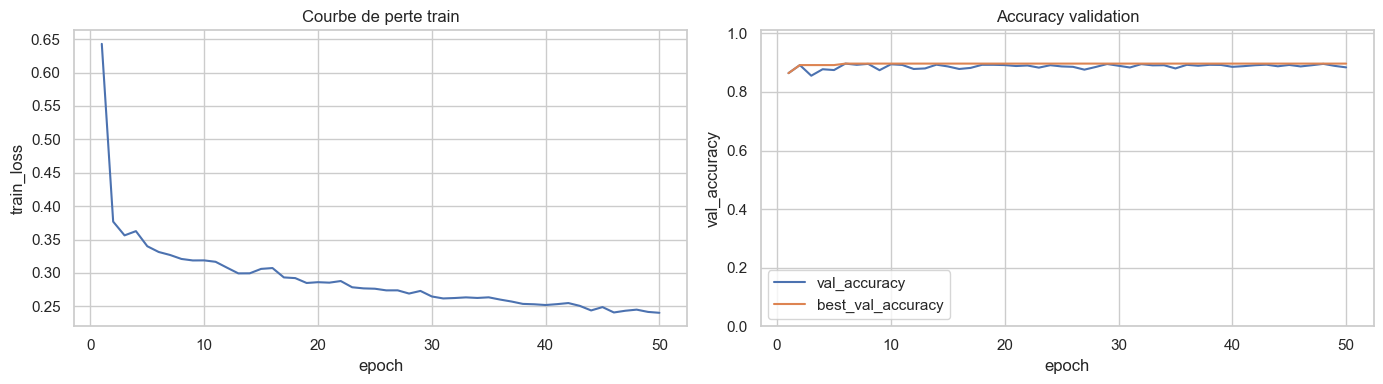

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=history_df, x='epoch', y='train_loss', ax=ax[0])
ax[0].set_title('Courbe de perte train')

sns.lineplot(data=history_df, x='epoch', y='val_accuracy', ax=ax[1], label='val_accuracy')
sns.lineplot(data=history_df, x='epoch', y='best_val_accuracy', ax=ax[1], label='best_val_accuracy')
ax[1].set_ylim(0.0, 1.01)
ax[1].set_title('Accuracy validation')
plt.tight_layout()
plt.show()

In [26]:
report_df = pd.DataFrame(test_metrics['classification_report']).transpose()
report_df

,precision,recall,f1-score,support
0,0.899614,0.879245,0.889313,265.00000
1,0.661017,0.750000,0.702703,104.00000
2,0.842949,0.806748,0.824451,326.00000
3,0.922961,0.861777,0.891320,709.00000
4,0.945170,0.937824,0.941482,386.00000
5,0.885057,0.948276,0.915577,406.00000
6,0.812274,0.853890,0.832562,527.00000
accuracy,0.874770,0.874770,0.874770,0.87477
macro avg,0.852720,0.862537,0.856773,2723.00000
weighted avg,0.877180,0.874770,0.875271,2723.00000


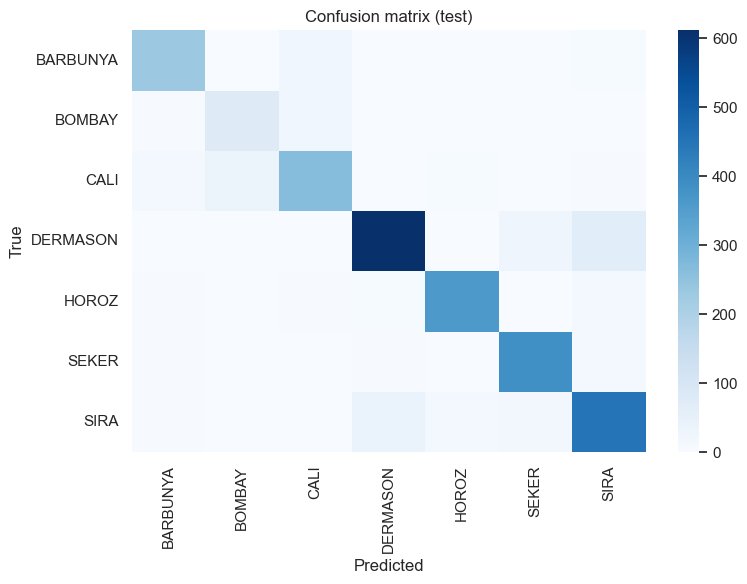

In [27]:
cm = np.array(test_metrics['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=splits.class_names, columns=splits.class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=False, cmap='Blues')
plt.title('Confusion matrix (test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Règles extraites depuis le main network généré

In [30]:
from IPython.display import display

rules = trainer.export_rules(top_per_rule=4, min_abs_weight=0.05)
rules_df = pd.DataFrame(rules)
print('Nombre de règles extraites:', len(rules_df))

# Affichage complet : pas de troncature des colonnes (surtout la liste `if`).
rules_df_show = rules_df.copy()
rules_df_show['if'] = rules_df_show['if'].apply(lambda conds: ' AND\n'.join(conds))

with pd.option_context(
    'display.max_colwidth', None,
    'display.max_rows', None,
    'display.width', None,
):
    display(rules_df_show)

Nombre de règles extraites: 64


,rule_id,if,then_class,score
0,34,"Roundness_x_Compactness_bin1_[0.325,0.501)=OFF AND\nShapeFactor1_bin0_[0.000,0.466)=OFF AND\nMinorAxisLength_bin3_[0.299,1.000)=OFF AND\nPerimeter_bin0_[0.000,0.117)=OFF",HOROZ,0.310294
1,51,"ShapeFactor4_bin0_[0.000,0.728)=OFF AND\nShapeFactor4_bin2_[0.857,0.928)=ON AND\nShapeFactor4_bin3_[0.928,1.000)=ON AND\nroundness_bin2_[0.646,0.779)=OFF",BARBUNYA,0.303183
2,12,"ShapeFactor1_bin3_[0.712,1.000)=OFF AND\nShapeFactor4_bin0_[0.000,0.728)=OFF AND\nroundness_bin2_[0.646,0.779)=OFF AND\nShapeFactor4_bin3_[0.928,1.000)=ON",BARBUNYA,0.266139
3,45,"ShapeFactor4_bin3_[0.928,1.000)=ON AND\nroundness_bin3_[0.779,1.000)=ON AND\nShapeFactor4_bin0_[0.000,0.728)=OFF AND\nroundness_bin2_[0.646,0.779)=OFF",BARBUNYA,0.243474
4,24,"ShapeFactor1_bin3_[0.712,1.000)=ON AND\nroundness_bin1_[0.444,0.646)=OFF AND\nShapeFactor1_bin0_[0.000,0.466)=OFF AND\nRoundness_x_Compactness_bin1_[0.325,0.501)=OFF",HOROZ,0.240913
5,10,"Area_over_Perimeter_bin2_[0.199,0.293)=ON AND\nMinorAxisLength_bin2_[0.200,0.299)=ON AND\nShapeFactor1_bin0_[0.000,0.466)=OFF AND\nShapeFactor1_bin1_[0.466,0.598)=ON",HOROZ,0.236109
6,11,"Area_over_Perimeter_bin2_[0.199,0.293)=OFF AND\nShapeFactor1_bin1_[0.466,0.598)=OFF AND\nMajorAxisLength_bin2_[0.208,0.396)=OFF AND\nShapeFactor2_bin1_[0.178,0.411)=OFF",BOMBAY,0.235556
7,23,"MinorAxisLength_bin0_[0.000,0.130)=ON AND\nArea_over_Perimeter_bin3_[0.293,1.000)=OFF AND\nShapeFactor1_bin3_[0.712,1.000)=ON AND\nroundness_bin0_[0.000,0.444)=OFF",DERMASON,0.235489
8,50,"ShapeFactor1_bin3_[0.712,1.000)=ON AND\nMinorAxisLength_bin0_[0.000,0.130)=ON AND\nSF_sum_bin0_[0.000,0.302)=ON AND\nEccentricity_bin1_[0.571,0.691)=OFF",HOROZ,0.232436
9,44,"Area_over_Perimeter_bin0_[0.000,0.135)=OFF AND\nShapeFactor1_bin2_[0.598,0.712)=OFF AND\nroundness_bin2_[0.646,0.779)=OFF AND\nShapeFactor1_bin3_[0.712,1.000)=OFF",BARBUNYA,0.226867


# Affichage d'une règle complète

In [ ]:
# Ici, "complète" = toutes les conditions dont |poids| >= min_abs_weight_full
# Mets min_abs_weight_full = 0.0 pour voir absolument tous les littéraux.
from nouveau_module.main_rule_net import unpack_main_params

assert trainer.model is not None

rule_id_to_show = int(rules_df.iloc[0]['rule_id'])  # change ici si tu veux une autre règle
min_abs_weight_full = 0.0

# On récupère les poids du main network générés par l'hyperréseau
x_probe = torch.zeros((16, trainer.model.input_dim_bin), device=trainer.device, dtype=torch.float32)
with torch.no_grad():
    theta_main, _ = trainer.model.hyper(x_probe)

w_rule, _, w_out, _ = unpack_main_params(
    theta_main,
    input_dim=trainer.model.input_dim_bin,
    num_rules=trainer.model.num_rules,
    num_classes=trainer.model.num_classes,
)

wr = w_rule[:, rule_id_to_show].detach().cpu().numpy()
bin_names = trainer.binarizer.binary_feature_names()

active_idx = [i for i in range(len(wr)) if abs(wr[i]) >= min_abs_weight_full]
active_idx = sorted(active_idx, key=lambda i: abs(wr[i]), reverse=True)

full_conditions = [
    f"{bin_names[i]}={'+1' if wr[i] >= 0 else '-1'} (w={wr[i]:+.4f})"
    for i in active_idx
]

then_class_idx = int(w_out[rule_id_to_show].argmax().item())
then_class = trainer.class_names[then_class_idx]

print(f"rule_id = {rule_id_to_show}")
print(f"then_class = {then_class}")
print(f"nb_conditions_affichees = {len(full_conditions)}")
print("\nIF")
print(" AND\n".join(full_conditions))
print(f"\nTHEN class = {then_class}")

rule_id = 34
then_class = HOROZ
nb_conditions_affichees = 96

IF
Roundness_x_Compactness_bin1_[0.325,0.501)=-1 (w=-0.3228) AND
ShapeFactor4_bin3_[0.928,1.000)=-1 (w=-0.2615) AND
Perimeter_bin0_[0.000,0.117)=-1 (w=-0.2594) AND
MinorAxisLength_bin3_[0.299,1.000)=-1 (w=-0.2579) AND
Roundness_x_Compactness_bin0_[0.000,0.325)=+1 (w=+0.2181) AND
ShapeFactor1_bin0_[0.000,0.466)=-1 (w=-0.2142) AND
ShapeFactor1_bin1_[0.466,0.598)=+1 (w=+0.1731) AND
Compactness_bin1_[0.346,0.492)=-1 (w=-0.1675) AND
Area_over_Perimeter_bin0_[0.000,0.135)=+1 (w=+0.1657) AND
roundness_bin3_[0.779,1.000)=-1 (w=-0.1548) AND
SF_sum_bin1_[0.302,0.452)=-1 (w=-0.1543) AND
Area_over_Perimeter_bin1_[0.135,0.199)=-1 (w=-0.1539) AND
ShapeFactor2_bin3_[0.618,1.000)=-1 (w=-0.1532) AND
Area_over_Perimeter_bin3_[0.293,1.000)=-1 (w=-0.1511) AND
roundness_bin0_[0.000,0.444)=+1 (w=+0.1482) AND
roundness_bin1_[0.444,0.646)=-1 (w=-0.1479) AND
Extent_bin0_[0.000,0.517)=+1 (w=+0.1385) AND
EquivDiameter_bin0_[0.000,0.125)=+1 (w=+0.1382)

# Analyse CF multi-cibles sur 10 samples correctement classés

In [ ]:
# Pour chaque sample, on génère un contrefactuel vers TOUTES les classes cibles (sauf la classe source).
model = trainer.model
assert model is not None

x_test_bin = trainer.binarizer.transform(splits.X_test)
x_test_t = torch.tensor(x_test_bin, dtype=torch.float32, device=trainer.device)
with torch.no_grad():
    logits_test = model.predict_logits(x_test_t)
    y_pred_test = torch.argmax(logits_test, dim=1).cpu().numpy()

correct_pool = np.where(y_pred_test == splits.y_test)[0]
rng = np.random.default_rng(42)
n_examples = min(10, len(correct_pool))
idx = rng.choice(correct_pool, size=n_examples, replace=False)

x_sub = torch.tensor(x_test_bin[idx], dtype=torch.float32, device=trainer.device)
y_sub = torch.tensor(splits.y_test[idx], dtype=torch.long, device=trainer.device)
y_pred_orig = torch.tensor(y_pred_test[idx], dtype=torch.long, device=trainer.device)

num_classes = len(splits.class_names)
with torch.no_grad():
    x_cf_all, logits_cf_all = model.generate_counterfactuals_all_classes(x_sub, y_pred_orig)
    y_pred_cf_all = torch.argmax(logits_cf_all, dim=2)  # [B, C]

x_sub_np = x_sub.cpu().numpy()
x_cf_all_np = x_cf_all.cpu().numpy()  # [B, C, D]
y_true_np = y_sub.cpu().numpy()
y_pred_orig_np = y_pred_orig.cpu().numpy()
y_pred_cf_all_np = y_pred_cf_all.cpu().numpy()

bin_names = trainer.binarizer.binary_feature_names()
rows = []
for i in range(n_examples):
    for target_cls in range(num_classes):
        # On saute la classe source, car ce n'est pas une cible CF.
        if target_cls == int(y_pred_orig_np[i]):
            continue

        delta_bits = np.abs(x_cf_all_np[i, target_cls] - x_sub_np[i])
        changed_idx = np.where(delta_bits > 1e-6)[0]
        top_idx = changed_idx[:8]

        rows.append(
            {
                'sample_index_test': int(idx[i]),
                'y_true': splits.class_names[int(y_true_np[i])],
                'y_pred_orig': splits.class_names[int(y_pred_orig_np[i])],
                'target_cf': splits.class_names[int(target_cls)],
                'y_pred_cf': splits.class_names[int(y_pred_cf_all_np[i, target_cls])],
                'valid_cf': bool(y_pred_cf_all_np[i, target_cls] == target_cls),
                'changed_bits_count': int(len(changed_idx)),
                'changed_bits_top': [bin_names[j] for j in top_idx],
            }
        )

cf_df = pd.DataFrame(rows)

print('Nb lignes = n_samples * (n_classes - 1) :', len(cf_df))
print('Taux global de validité CF :', f"{cf_df['valid_cf'].mean():.4f}")

# Vue détaillée par (sample, cible)
cf_df

Nb lignes = n_samples * (n_classes - 1) : 60
Taux global de validité CF : 1.0000


,sample_index_test,y_true,y_pred_orig,target_cf,y_pred_cf,valid_cf,changed_bits_count,changed_bits_top
0,235,CALI,CALI,BARBUNYA,BARBUNYA,True,13,"[MajorAxisLength_bin2_[0.208,0.396), MajorAxis..."
1,235,CALI,CALI,BOMBAY,BOMBAY,True,23,"[Area_bin3_[0.229,1.000), MinorAxisLength_bin0..."
2,235,CALI,CALI,DERMASON,DERMASON,True,24,"[Perimeter_bin0_[0.000,0.117), MajorAxisLength..."
3,235,CALI,CALI,HOROZ,HOROZ,True,25,"[MinorAxisLength_bin0_[0.000,0.130), MinorAxis..."
4,235,CALI,CALI,SEKER,SEKER,True,37,"[MajorAxisLength_bin0_[0.000,0.103), MajorAxis..."
5,235,CALI,CALI,SIRA,SIRA,True,30,"[Area_bin3_[0.229,1.000), Perimeter_bin2_[0.20..."
6,2102,DERMASON,DERMASON,BARBUNYA,BARBUNYA,True,19,"[Perimeter_bin1_[0.117,0.202), MajorAxisLength..."
7,2102,DERMASON,DERMASON,BOMBAY,BOMBAY,True,22,"[Area_bin1_[0.074,0.126), Perimeter_bin0_[0.00..."
8,2102,DERMASON,DERMASON,CALI,CALI,True,27,"[Area_bin1_[0.074,0.126), Area_bin3_[0.229,1.0..."
9,2102,DERMASON,DERMASON,HOROZ,HOROZ,True,22,"[Area_bin1_[0.074,0.126), Perimeter_bin1_[0.11..."


# Contrefactuels complets pour UNE prediction vers TOUTES les classes cibles

In [33]:

sample_pos = 0  # position dans les 10 samples tirés (cellule précédente)

model = trainer.model
assert model is not None

# Récupération de l'index test du sample choisi dans la cellule précédente
sample_index_test = int(idx[sample_pos])
y_true_idx = int(splits.y_test[sample_index_test])

y_source_name = splits.class_names[y_true_idx]

# Encodage binaire du sample
x_bin_full = trainer.binarizer.transform(splits.X_test)
x_src_bin = torch.tensor(x_bin_full[sample_index_test:sample_index_test+1], dtype=torch.float32, device=trainer.device)

# Dans ce notebook, la classe source est correctement prédite (pool filtré en amont)
y_source = torch.tensor([y_true_idx], dtype=torch.long, device=trainer.device)

with torch.no_grad():
    x_cf_all, logits_cf_all = model.generate_counterfactuals_all_classes(x_src_bin, y_source)

x_src_bin_np = x_src_bin[0].cpu().numpy()
x_src_cont = trainer.binarizer.binary_to_continuous(x_src_bin_np.reshape(1, -1))[0]
bin_names = trainer.binarizer.binary_feature_names()

print('Sample index test :', sample_index_test)
print('y_true / source   :', y_source_name)

for target_idx, target_name in enumerate(splits.class_names):
    if target_idx == y_true_idx:
        continue

    x_cf_bin = x_cf_all[0, target_idx].cpu().numpy()
    y_pred_cf_idx = int(torch.argmax(logits_cf_all[0, target_idx]).item())

    changed_idx = np.where(np.abs(x_cf_bin - x_src_bin_np) > 1e-6)[0]

    # Projection continue pour lecture humaine
    x_cf_cont = trainer.binarizer.binary_to_continuous(x_cf_bin.reshape(1, -1))[0]

    rows_bits = []
    for j in changed_idx:
        rows_bits.append(
            {
                'binary_feature': bin_names[j],
                'src_bit': int(x_src_bin_np[j]),
                'cf_bit': int(x_cf_bin[j]),
            }
        )
    changes_bits_df = pd.DataFrame(rows_bits)
    if not changes_bits_df.empty:
        # Garde uniquement les vrais flips de bits.
        changes_bits_df = changes_bits_df.loc[changes_bits_df['src_bit'] != changes_bits_df['cf_bit']].reset_index(drop=True)

    cont_changes_df = pd.DataFrame(
        {
            'feature': splits.feature_names,
            'x_src_cont': x_src_cont,
            'x_cf_cont': x_cf_cont,
            'delta': x_cf_cont - x_src_cont,
        }
    )
    cont_changes_df = cont_changes_df.loc[cont_changes_df['delta'].abs() > 1e-9].sort_values('delta', key=np.abs, ascending=False)

    print('\n' + '=' * 90)
    print('target_cf         :', target_name)
    print('y_pred_cf         :', splits.class_names[y_pred_cf_idx])
    print('valid_cf          :', y_pred_cf_idx == target_idx)
    print('changed_bits_count:', len(changed_idx))

    print('\nBits modifiés (complet):')
    display(changes_bits_df)

    print('\nProjection continue (features effectivement changées):')
    display(cont_changes_df)

Sample index test : 235
y_true / source   : CALI

target_cf         : BARBUNYA
y_pred_cf         : BARBUNYA
valid_cf          : True
changed_bits_count: 15

Bits modifiés (complet):


,binary_feature,src_bit,cf_bit
0,"MajorAxisLength_bin2_[0.208,0.396)",0,1
1,"MajorAxisLength_bin3_[0.396,1.000)",1,0
2,"MinorAxisLength_bin1_[0.130,0.200)",0,1
3,"ConvexArea_bin3_[0.230,1.000)",1,0
4,"Extent_bin1_[0.517,0.702)",1,0
5,"Solidity_bin0_[0.000,0.681)",0,1
6,"roundness_bin2_[0.646,0.779)",1,0
7,"ShapeFactor2_bin1_[0.178,0.411)",1,0
8,"ShapeFactor4_bin0_[0.000,0.728)",1,0
9,"Area_over_Perimeter_bin3_[0.293,1.000)",1,0



Projection continue (features effectivement changées):


,feature,x_src_cont,x_cf_cont,delta
15,ShapeFactor4,0.364231,0.964237,0.600007
16,Area_over_Perimeter,0.646659,0.067440,-0.579220
6,ConvexArea,0.615067,0.036573,-0.578494
10,roundness,0.712374,0.221799,-0.490575
3,MinorAxisLength,0.649509,0.164969,-0.484540
9,Solidity,0.738830,0.340433,-0.398397
2,MajorAxisLength,0.698193,0.301979,-0.396213
8,Extent,0.609492,0.911095,0.301604
19,Roundness_x_Compactness,0.412968,0.162455,-0.250513
13,ShapeFactor2,0.294817,0.089249,-0.205569



target_cf         : BOMBAY
y_pred_cf         : BOMBAY
valid_cf          : True
changed_bits_count: 19

Bits modifiés (complet):


...

,feature,x_src_cont,x_cf_cont,delta
2,MajorAxisLength,0.698193,0.051290,-0.646903
23,log_ConvexArea,0.728217,0.097464,-0.630753
21,log_Area,0.727671,0.098138,-0.629533
15,ShapeFactor4,0.364231,0.964237,0.600007
16,Area_over_Perimeter,0.646659,0.067440,-0.579220
6,ConvexArea,0.615067,0.036573,-0.578494
1,Perimeter,0.685530,0.159228,-0.526302
13,ShapeFactor2,0.294817,0.809108,0.514290
22,log_Perimeter,0.749728,0.245087,-0.504641
7,EquivDiameter,0.666780,0.163156,-0.503624



target_cf         : SIRA
y_pred_cf         : SIRA
valid_cf          : True
changed_bits_count: 25

Bits modifiés (complet):


,binary_feature,src_bit,cf_bit
0,"Area_bin3_[0.229,1.000)",1,0
1,"MajorAxisLength_bin3_[0.396,1.000)",1,0
2,"MinorAxisLength_bin3_[0.299,1.000)",1,0
3,"AspectRation_bin2_[0.385,0.530)",1,0
4,"Eccentricity_bin2_[0.691,0.803)",1,0
5,"Eccentricity_bin3_[0.803,1.000)",0,1
6,"EquivDiameter_bin0_[0.000,0.125)",0,1
7,"EquivDiameter_bin1_[0.125,0.201)",0,1
8,"EquivDiameter_bin3_[0.334,1.000)",1,0
9,"Extent_bin1_[0.517,0.702)",1,0



Projection continue (features effectivement changées):


,feature,x_src_cont,x_cf_cont,delta
22,log_Perimeter,0.749728,0.093412,-0.656316
2,MajorAxisLength,0.698193,0.051290,-0.646903
23,log_ConvexArea,0.728217,0.097464,-0.630753
21,log_Area,0.727671,0.098138,-0.629533
7,EquivDiameter,0.666780,0.062550,-0.604230
0,Area,0.614616,0.036867,-0.577749
3,MinorAxisLength,0.649509,0.164969,-0.484540
12,ShapeFactor1,0.232940,0.655317,0.422377
16,Area_over_Perimeter,0.646659,0.246236,-0.400423
8,Extent,0.609492,0.258630,-0.350862


## Lecture rapide

- `accuracy` / `AUROC`: qualité de classification.
- `CF validity`: proportion de CF atteignant la classe cible.
- Dans la table `cf_df`, chaque ligne correspond à un couple `(sample, target_cf)`.
- `changed_bits_count`: nombre de bits modifiés pour atteindre la cible.
- `rules_df`: règles IF-THEN extraites du main network.